<p style="text-align:center">
    <a href="https://skills.network" target="_blank">
    <img src="https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/assets/logos/SN_web_lightmode.png" width="200" alt="Skills Network Logo"  />
    </a>
</p>


# **Data Normalization Techniques**


Estimated time needed: **30** minutes


In this lab, you will focus on data normalization. This includes identifying compensation-related columns, applying normalization techniques, and visualizing the data distributions.


## Objectives


In this lab, you will perform the following:


- Identify duplicate rows and remove them.

- Check and handle missing values in key columns.

- Identify and normalize compensation-related columns.

- Visualize the effect of normalization techniques on data distributions.


-----


## Hands on Lab


#### Step 1: Install and Import Libraries


In [13]:
!pip install pandas

In [14]:
!pip install matplotlib

In [15]:
import pandas as pd
import matplotlib.pyplot as plt

### Step 2: Load the Dataset into a DataFrame


We use the <code>pandas.read_csv()</code> function for reading CSV files. However, in this version of the lab, which operates on JupyterLite, the dataset needs to be downloaded to the interface using the provided code below.


The functions below will download the dataset into your browser:


In [16]:
file_path ="https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/UDKAZw-kz18Yj8P6icf_qw/survey-data-duplicates.csv"

df = pd.read_csv(file_path)

# Display the first few rows to check if data is loaded correctly
print(df.head())


   ResponseId                      MainBranch                 Age  \
0           1  I am a developer by profession  Under 18 years old   
1           2  I am a developer by profession     35-44 years old   
2           3  I am a developer by profession     45-54 years old   
3           4           I am learning to code     18-24 years old   
4           5  I am a developer by profession     18-24 years old   

            Employment RemoteWork   Check  \
0  Employed, full-time     Remote  Apples   
1  Employed, full-time     Remote  Apples   
2  Employed, full-time     Remote  Apples   
3   Student, full-time        NaN  Apples   
4   Student, full-time        NaN  Apples   

                                    CodingActivities  \
0                                              Hobby   
1  Hobby;Contribute to open-source projects;Other...   
2  Hobby;Contribute to open-source projects;Other...   
3                                                NaN   
4                                 

In [17]:
#df = pd.read_csv("https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/UDKAZw-kz18Yj8P6icf_qw/survey-data-duplicates.csv")

### Section 1: Handling Duplicates
##### Task 1: Identify and remove duplicate rows.


In [18]:
# 1. Identify the number of duplicate rows
duplicate_count = df.duplicated().sum()
print(f"Number of duplicate rows: {duplicate_count}")

# 2. Remove duplicate rows by reassigning the DataFrame
# By default, drop_duplicates() returns a NEW DataFrame.
df = df.drop_duplicates()

# 3. Verify the result
print(f"Number of duplicate rows after removal: {df.duplicated().sum()}")
print(f"New total row count: {len(df)}")

Number of duplicate rows: 10
Number of duplicate rows after removal: 0
New total row count: 65437


### Section 2: Handling Missing Values
##### Task 2: Identify missing values in `CodingActivities`.


In [19]:
## Write your code here
# Identify the number of missing values in the 'CodingActivities' column
missing_coding_activities = df['CodingActivities'].isnull().sum()

print(f"Number of missing values in 'CodingActivities': {missing_coding_activities}")

Number of missing values in 'CodingActivities': 10971


##### Task 3: Impute missing values in CodingActivities with forward-fill.


In [20]:
## Write your code here
# 1. Check the number of missing values before imputation
missing_before = df['CodingActivities'].isnull().sum()
print(f"Number of missing values in 'CodingActivities' before: {missing_before}")

# 2. Apply forward-fill to the column
# We reassign the result back to the column to avoid using inplace=True
df['CodingActivities'] = df['CodingActivities'].ffill()

# 3. Verify that the missing values are filled
missing_after = df['CodingActivities'].isnull().sum()
print(f"Number of missing values in 'CodingActivities' after: {missing_after}")

Number of missing values in 'CodingActivities' before: 10971
Number of missing values in 'CodingActivities' after: 0


**Note**:  Before normalizing ConvertedCompYearly, ensure that any missing values (NaN) in this column are handled appropriately. You can choose to either drop the rows containing NaN or replace the missing values with a suitable statistic (e.g., median or mean).


### Section 3: Normalizing Compensation Data
##### Task 4: Identify compensation-related columns, such as ConvertedCompYearly.
Normalization is commonly applied to compensation data to bring values within a comparable range. Here, you’ll identify ConvertedCompYearly or similar columns, which contain compensation information. This column will be used in the subsequent tasks for normalization.


In [21]:
## Write your code here
# 1. List all columns to see the dataset structure
print("All column names:")
print(df.columns.tolist())

# 2. Search for columns containing "Comp" or "Salary" (case-insensitive)
comp_related_columns = [col for col in df.columns if 'comp' in col.lower() or 'salary' in col.lower()]

print("\nIdentified compensation-related columns:")
print(comp_related_columns)

# 3. Preview the main column for normalization
if 'ConvertedCompYearly' in df.columns:
    print("\nPreview of 'ConvertedCompYearly':")
    print(df[['ConvertedCompYearly']].head())

All column names:
['ResponseId', 'MainBranch', 'Age', 'Employment', 'RemoteWork', 'Check', 'CodingActivities', 'EdLevel', 'LearnCode', 'LearnCodeOnline', 'TechDoc', 'YearsCode', 'YearsCodePro', 'DevType', 'OrgSize', 'PurchaseInfluence', 'BuyNewTool', 'BuildvsBuy', 'TechEndorse', 'Country', 'Currency', 'CompTotal', 'LanguageHaveWorkedWith', 'LanguageWantToWorkWith', 'LanguageAdmired', 'DatabaseHaveWorkedWith', 'DatabaseWantToWorkWith', 'DatabaseAdmired', 'PlatformHaveWorkedWith', 'PlatformWantToWorkWith', 'PlatformAdmired', 'WebframeHaveWorkedWith', 'WebframeWantToWorkWith', 'WebframeAdmired', 'EmbeddedHaveWorkedWith', 'EmbeddedWantToWorkWith', 'EmbeddedAdmired', 'MiscTechHaveWorkedWith', 'MiscTechWantToWorkWith', 'MiscTechAdmired', 'ToolsTechHaveWorkedWith', 'ToolsTechWantToWorkWith', 'ToolsTechAdmired', 'NEWCollabToolsHaveWorkedWith', 'NEWCollabToolsWantToWorkWith', 'NEWCollabToolsAdmired', 'OpSysPersonal use', 'OpSysProfessional use', 'OfficeStackAsyncHaveWorkedWith', 'OfficeStackAsy

##### Task 5: Normalize ConvertedCompYearly using Min-Max Scaling.
Min-Max Scaling brings all values in a column to a 0-1 range, making it useful for comparing data across different scales. Here, you will apply Min-Max normalization to the ConvertedCompYearly column, creating a new column ConvertedCompYearly_MinMax with normalized values.


In [22]:
## Write your code here
# 1. Define the scaling parameters
min_val = df['ConvertedCompYearly'].min()
max_val = df['ConvertedCompYearly'].max()

# 2. Apply the Min-Max formula: (x - min) / (max - min)
# We create a new column to keep the original data intact
df['ConvertedCompYearly_MinMax'] = (df['ConvertedCompYearly'] - min_val) / (max_val - min_val)

# 3. Preview the original and normalized columns
print("Comparison of raw values vs. normalized values:")
print(df[['ConvertedCompYearly', 'ConvertedCompYearly_MinMax']].head())

# 4. Verify the range (should be 0.0 to 1.0)
print(f"\nMinimum of normalized column: {df['ConvertedCompYearly_MinMax'].min()}")
print(f"Maximum of normalized column: {df['ConvertedCompYearly_MinMax'].max()}")


Comparison of raw values vs. normalized values:
   ConvertedCompYearly  ConvertedCompYearly_MinMax
0                  NaN                         NaN
1                  NaN                         NaN
2                  NaN                         NaN
3                  NaN                         NaN
4                  NaN                         NaN

Minimum of normalized column: 0.0
Maximum of normalized column: 1.0


##### Task 6: Apply Z-score Normalization to `ConvertedCompYearly`.

Z-score normalization standardizes values by converting them to a distribution with a mean of 0 and a standard deviation of 1. This method is helpful for datasets with a Gaussian (normal) distribution. Here, you’ll calculate Z-scores for the ConvertedCompYearly column, saving the results in a new column ConvertedCompYearly_Zscore.


In [25]:
## Write your code here
# 1. Calculate the mean and standard deviation
mean_comp = df['ConvertedCompYearly'].mean()
std_comp = df['ConvertedCompYearly'].std()

# 2. Apply the Z-score formula: (x - mean) / std
# We save the result in a new column
df['ConvertedCompYearly_Zscore'] = (df['ConvertedCompYearly'] - mean_comp) / std_comp

# 3. Preview the results
print("Raw values vs. Z-scores:")
print(df[['ConvertedCompYearly', 'ConvertedCompYearly_Zscore']].head())

# 4. Verify the new distribution (Mean should be ~0, Std should be ~1)
print(f"\nMean of Z-score column: {df['ConvertedCompYearly_Zscore'].mean():.2f}")
print(f"Standard Deviation of Z-score column: {df['ConvertedCompYearly_Zscore'].std():.2f}")

Raw values vs. Z-scores:
   ConvertedCompYearly  ConvertedCompYearly_Zscore
0                  NaN                         NaN
1                  NaN                         NaN
2                  NaN                         NaN
3                  NaN                         NaN
4                  NaN                         NaN

Mean of Z-score column: 0.00
Standard Deviation of Z-score column: 1.00


In [24]:
# 1. Count how many rows actually have numerical data (Not NaN)
non_null_count = df['ConvertedCompYearly'].notnull().sum()
print(f"Total rows with valid compensation data: {non_null_count}")

# 2. Display the first 5 rows that are NOT NaN
# This filters out the empty rows so you can see the actual numbers
print("\nFirst 5 rows with actual numerical values:")
print(df[df['ConvertedCompYearly'].notnull()][['ConvertedCompYearly']].head())

Total rows with valid compensation data: 23435

First 5 rows with actual numerical values:
     ConvertedCompYearly
72                7322.0
374              30074.0
379              91295.0
385              53703.0
389             110000.0


### Section 4: Visualization of Normalized Data
##### Task 7: Visualize the distribution of `ConvertedCompYearly`, `ConvertedCompYearly_Normalized`, and `ConvertedCompYearly_Zscore`

Visualization helps you understand how normalization changes the data distribution. In this task, create histograms for the original ConvertedCompYearly, as well as its normalized versions (ConvertedCompYearly_MinMax and ConvertedCompYearly_Zscore). This will help you compare how each normalization technique affects the data range and distribution.


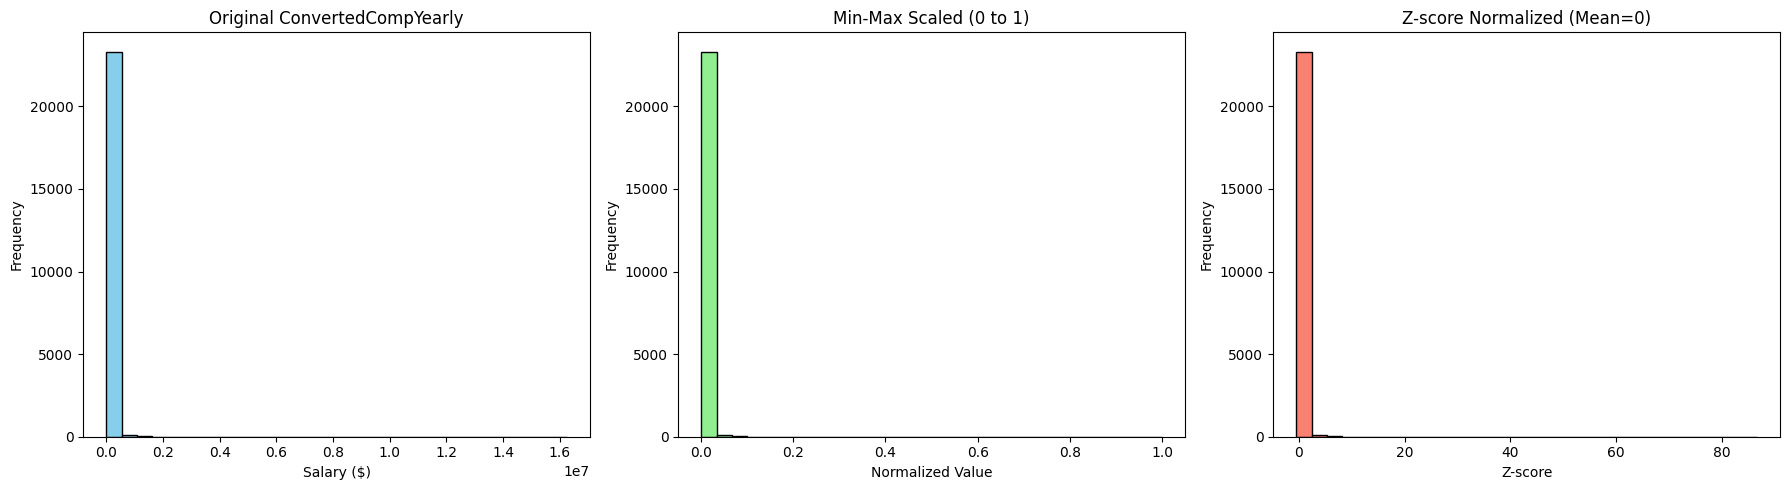

In [26]:
## Write your code here
import matplotlib.pyplot as plt

# Create a figure with 3 subplots side-by-side
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1. Histogram for Original Data
axes[0].hist(df['ConvertedCompYearly'].dropna(), bins=30, color='skyblue', edgecolor='black')
axes[0].set_title('Original ConvertedCompYearly')
axes[0].set_xlabel('Salary ($)')
axes[0].set_ylabel('Frequency')

# 2. Histogram for Min-Max Scaled Data
axes[1].hist(df['ConvertedCompYearly_MinMax'].dropna(), bins=30, color='lightgreen', edgecolor='black')
axes[1].set_title('Min-Max Scaled (0 to 1)')
axes[1].set_xlabel('Normalized Value')
axes[1].set_ylabel('Frequency')

# 3. Histogram for Z-score Normalized Data
axes[2].hist(df['ConvertedCompYearly_Zscore'].dropna(), bins=30, color='salmon', edgecolor='black')
axes[2].set_title('Z-score Normalized (Mean=0)')
axes[2].set_xlabel('Z-score')
axes[2].set_ylabel('Frequency')

plt.tight_layout()
plt.show()


### Summary


In this lab, you practiced essential normalization techniques, including:

- Identifying and handling duplicate rows.

- Checking for and imputing missing values.

- Applying Min-Max scaling and Z-score normalization to compensation data.

- Visualizing the impact of normalization on data distribution.


Copyright © IBM Corporation. All rights reserved.
